In [1]:
# [Cell 1] 环境配置、物理拓扑与全局控制 (Jupyter 独立运行基石)
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random


# ------------------------------------------
# 🔒 1. 核心控制台：锁定所有随机性
# ------------------------------------------
def set_seed(seed=42):
    """锁定 PyTorch、Numpy 和 Python 所有的底层骰子"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_obs_indices(num_nodes=33, seed=42):
    """动态但固定地生成 15% 观测点 (永远包含 0 号平衡节点)"""
    random.seed(seed)  # 局部锁死
    num_obs = int(num_nodes * 0.15)  # 33节点约 4.95 -> 4 个附加点 + 1 个平衡点 = 5 个点
    all_idx = list(range(1, num_nodes))
    return [0] + sorted(random.sample(all_idx, num_obs - 1))


# 初始化全局状态
set_seed(42)
global_obs_indices = get_obs_indices(33, 42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 炼丹炉就绪! 算力: {device}")
print(f"📡 锁定的 15% PMU 观测点: {global_obs_indices}")

# ------------------------------------------
# ⚡ 2. 提取 33 节点导纳矩阵 Ybus
# ------------------------------------------
branch_data = np.array([
    [1, 2, 0.00057, 0.00029], [2, 3, 0.00307, 0.00156], [3, 4, 0.00228, 0.00117],
    [4, 5, 0.00237, 0.00121], [5, 6, 0.00511, 0.00441], [6, 7, 0.00116, 0.00336],
    [7, 8, 0.00443, 0.00146], [8, 9, 0.00642, 0.00461], [9, 10, 0.00651, 0.00461],
    [10, 11, 0.00122, 0.00040], [11, 12, 0.00233, 0.00074], [12, 13, 0.00915, 0.00720],
    [13, 14, 0.00337, 0.00444], [14, 15, 0.00368, 0.00328], [15, 16, 0.00465, 0.00340],
    [16, 17, 0.00804, 0.01073], [17, 18, 0.00456, 0.00358], [2, 19, 0.00102, 0.00097],
    [19, 20, 0.00938, 0.00845], [20, 21, 0.00255, 0.00298], [21, 22, 0.00442, 0.00584],
    [3, 23, 0.00281, 0.00192], [23, 24, 0.00560, 0.00442], [24, 25, 0.00559, 0.00437],
    [6, 26, 0.00126, 0.00064], [26, 27, 0.00177, 0.00090], [27, 28, 0.00660, 0.00582],
    [28, 29, 0.00501, 0.00437], [29, 30, 0.00316, 0.00161], [30, 31, 0.00608, 0.00600],
    [31, 32, 0.00193, 0.00225], [32, 33, 0.00212, 0.00330]
])

num_nodes = 33
y_bus = np.zeros((num_nodes, num_nodes), dtype=complex)
for i in range(len(branch_data)):
    f, t = int(branch_data[i, 0] - 1), int(branch_data[i, 1] - 1)
    y_line = 1 / (branch_data[i, 2] + 1j * branch_data[i, 3])
    y_bus[f, f] += y_line
    y_bus[t, t] += y_line
    y_bus[f, t] = y_bus[t, f] = -y_line

G_tensor = torch.tensor(y_bus.real, dtype=torch.float32).to(device)
B_tensor = torch.tensor(y_bus.imag, dtype=torch.float32).to(device)


# ==============================================================================
# [Cell 2] 核心武器库：物理方程、网络架构与观测控制 (Jupyter 独立版)
# ==============================================================================

# ------------------------------------------
# 1. 物理考卷控制：随机但可控地抽取观测点
# ------------------------------------------
def get_obs_indices(num_nodes=33, seed=42):
    """
    不管在哪个单元格运行，只要 seed 一样，选出的 15% 观测点位置就一模一样。
    """
    random.seed(seed)
    num_obs = int(num_nodes * 0.15)  # 约 5 个点
    all_idx = list(range(1, num_nodes))  # 排除平衡节点
    # 强制包含 0 号平衡节点，剩下随机抽
    return [0] + sorted(random.sample(all_idx, num_obs - 1))


# ------------------------------------------
# 2. 盲区遮蔽引擎：模拟只有 15% 传感器的数据流
# ------------------------------------------
def apply_blind_zone(batch_x, obs_indices, mean_t, scale_t):
    """
    把非观测节点的数据全部抹成“物理零点（均值）”，实现空间维度的遮蔽。
    """
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]  # P 注入
        masked_x[:, idx + 33] = batch_x[:, idx + 33]  # Q 注入
    return masked_x


# ------------------------------------------
# 3. 潮流方程引擎：PyTorch 矩阵化计算 (KCL 的神经网络实现)
# ------------------------------------------
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    """
    核心：通过电压幅值和相角差，利用导纳矩阵反推节点 P, Q
    """
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_matrix = torch.cos(delta_theta)
    sin_matrix = torch.sin(delta_theta)

    # 物理算子: G*cos + B*sin
    p_term = G_t * cos_matrix + B_t * sin_matrix
    q_term = G_t * sin_matrix - B_t * cos_matrix

    # 全局加权求和
    sum_p = torch.sum(V_pred.unsqueeze(1) * p_term, dim=2)
    sum_q = torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)

    P_calc = V_pred * sum_p
    Q_calc = V_pred * sum_q
    return P_calc, Q_calc


# ------------------------------------------
# 4. R-PINN 网络架构：带 Asymmetric Residual Scaling (ARS)
# ------------------------------------------
class PowerGridPINN(nn.Module):
    def __init__(self, input_dim=66):
        super(PowerGridPINN, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256)
        )
        self.output_layers = nn.Linear(256, 66)

    def forward(self, x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)

        # --- 核心 ARS 机制 ---
        # 标幺值系统电压在 1.0 附近，相角在 0 附近，残差学习极大加速收敛
        Vm_pred = output[:, :33] * 0.1 + 1.0
        theta_pred = output[:, 33:] * 0.01 + 0.0

        # 锚定平衡节点常识：Bus 0 永远是 (1.0, 0.0)
        Vm_pred[:, 0] = 1.0
        theta_pred[:, 0] = 0.0
        return Vm_pred, theta_pred


# ------------------------------------------
# 5. 联合 Loss 函数：数据锚定 + 物理一致性 + 电压墙
# ------------------------------------------
class PowerPINNLoss(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse_tool = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real_target, Q_real_target, V_real, p_weight, obs_weight=500000):
        # 1. 潮流物理残差 (KCL 约束)
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        P_loss = self.mse_tool(P_calc, P_real_target)
        Q_loss = self.mse_tool(Q_calc, Q_real_target)

        # 2. 观测点数据偏差 (蓝星锚定)
        V_obs_pred = V_pred[:, self.obs_idx]
        V_obs_real = V_real[:, self.obs_idx]
        obs_loss = torch.sum((V_obs_pred - V_obs_real) ** 2)

        # 3. 边界壁垒 (防止电压越限)
        # 用 ReLU 实现：如果电压在 0.85-1.1 之间，Loss=0；否则罚得它亲妈都不认识
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.1)

        return (
                p_weight * (P_loss + Q_loss) +
                1000 * torch.mean(penalty_low + penalty_high) +
                obs_weight * obs_loss
        )


# ------------------------------------------
# 6. 数据装载器
# ------------------------------------------
class MyDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx): return self.features[idx], self.labels[idx]


print("✅ Cell 2 [完全体] 加载完毕！物理引擎、网络架构和独立种子机制已全部就位。")
# ==========================================
# [Cell 3] 数据引擎：脱水、归一化与全链条种子锁定
# ==========================================

# 🚀 绝杀操作：在加载数据前再次重置种子，确保 DataLoader 的 shuffle 逻辑被物理锁死
set_seed(42)

print("📥 正在从本地磁盘读取 50,000 条 33 节点物理样本...")
# 注意：路径请保持你电脑上的原始路径
df = pd.read_csv(r'D:\PycharmWork\pythonProject\IEEE33_50000_Safe_Final.csv')
raw_data = df.values
m = raw_data.shape[0]

# 1. 物理维度重塑 [样本数, 节点数, 特征数(P, Q, V, Theta)]
data_3d = raw_data.reshape(m, 33, 4)

# 2. 物理脱水：兆瓦(MW/MVar) -> 标幺值(p.u.) 
# 这一步极其专业，让物理方程的数值量级保持在 [0, 1] 之间
P_real_pu = data_3d[:, :, 0].copy() / 100.0  # 基准功率取 100MVA
Q_real_pu = data_3d[:, :, 1].copy() / 100.0
V_real_pu = data_3d[:, :, 2].copy()  # 电压本来就是标幺值

# 3. 输入特征归一化 (StandardScaler)
# AI 喜欢零均值、单位方差的数据，这能让 Loss 降得更快
X_raw = data_3d[:, :, 0:2].reshape(m, 66)  # 展开成 66 维输入
ssl = StandardScaler()
X_norm = ssl.fit_transform(X_raw)

# 4. 提取归一化参数，转化为 Tensor 供 apply_blind_zone 使用
# 这样在盲区遮蔽时，我们才能把盲区节点准确地抹成“统计学零点”
mean_tensor = torch.tensor(ssl.mean_, dtype=torch.float32).to(device)
scale_tensor = torch.tensor(ssl.scale_, dtype=torch.float32).to(device)

# 5. 目标值拼装 [P(33), Q(33), V(33)] -> 总共 99 维
PQV_target_up = np.concatenate([P_real_pu, Q_real_pu, V_real_pu], axis=1)

# 6. 转化为 GPU 计算张量
X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)
PQ_target_tensor = torch.tensor(PQV_target_up, dtype=torch.float32).to(device)

# 7. 创建数据集与装载器
# 这里的 generator 是为了二次锁死 DataLoader 内部的随机洗牌顺序
g = torch.Generator()
g.manual_seed(42)

train_dataset = MyDataset(X_tensor, PQ_target_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,  # 虽然是洗牌，但因为有种子，洗牌的顺序是永久固定的
    generator=g  # 锁定洗牌发生器
)

print("-" * 50)
print(f"✅ 数据引擎装载完毕！")
print(f"📊 样本总数: {m} | 输入维度: 66 | 目标维度: 99")
print(f"🔒 数据洗牌顺序已锁定，实验可复现性：100%")
print("-" * 50)

🚀 炼丹炉就绪! 算力: cuda
📡 锁定的 15% PMU 观测点: [0, 2, 8, 18]
✅ Cell 2 [完全体] 加载完毕！物理引擎、网络架构和独立种子机制已全部就位。
📥 正在从本地磁盘读取 50,000 条 33 节点物理样本...
--------------------------------------------------
✅ 数据引擎装载完毕！
📊 样本总数: 50000 | 输入维度: 66 | 目标维度: 99
🔒 数据洗牌顺序已锁定，实验可复现性：100%
--------------------------------------------------


🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: 1.0% | 观测点: [0, 2, 8, 18]
Epoch 0   | Avg Loss: 312014.0586 | LR: 0.001
Epoch 10  | Avg Loss: 25283.2080 | LR: 0.001
Epoch 20  | Avg Loss: 25207.1810 | LR: 0.001
Epoch 30  | Avg Loss: 25180.7632 | LR: 0.001
Epoch 40  | Avg Loss: 25187.8233 | LR: 0.0005
Epoch 50  | Avg Loss: 26437.7993 | LR: 0.0005
Epoch 60  | Avg Loss: 26441.0487 | LR: 0.0005
Epoch 70  | Avg Loss: 26439.2675 | LR: 0.0005
Epoch 80  | Avg Loss: 26234.7280 | LR: 0.00025
Epoch 90  | Avg Loss: 26178.9964 | LR: 0.00025
Epoch 100 | Avg Loss: 26364.4752 | LR: 0.00025
Epoch 110 | Avg Loss: 26226.9264 | LR: 0.00025
Epoch 120 | Avg Loss: 26323.1398 | LR: 0.000125
Epoch 130 | Avg Loss: 26279.2044 | LR: 0.000125
Epoch 140 | Avg Loss: 26352.7654 | LR: 0.000125

🛡️ [鲁棒性测试结果] Noise Level: 1.0%
-----------------------------------------------------------------
🌍 MAE under 1.0% Noise:  3.010464e-03 p.u.
🔥 RMSE under 1.0% Noise: 4.203507e-03 p.u.


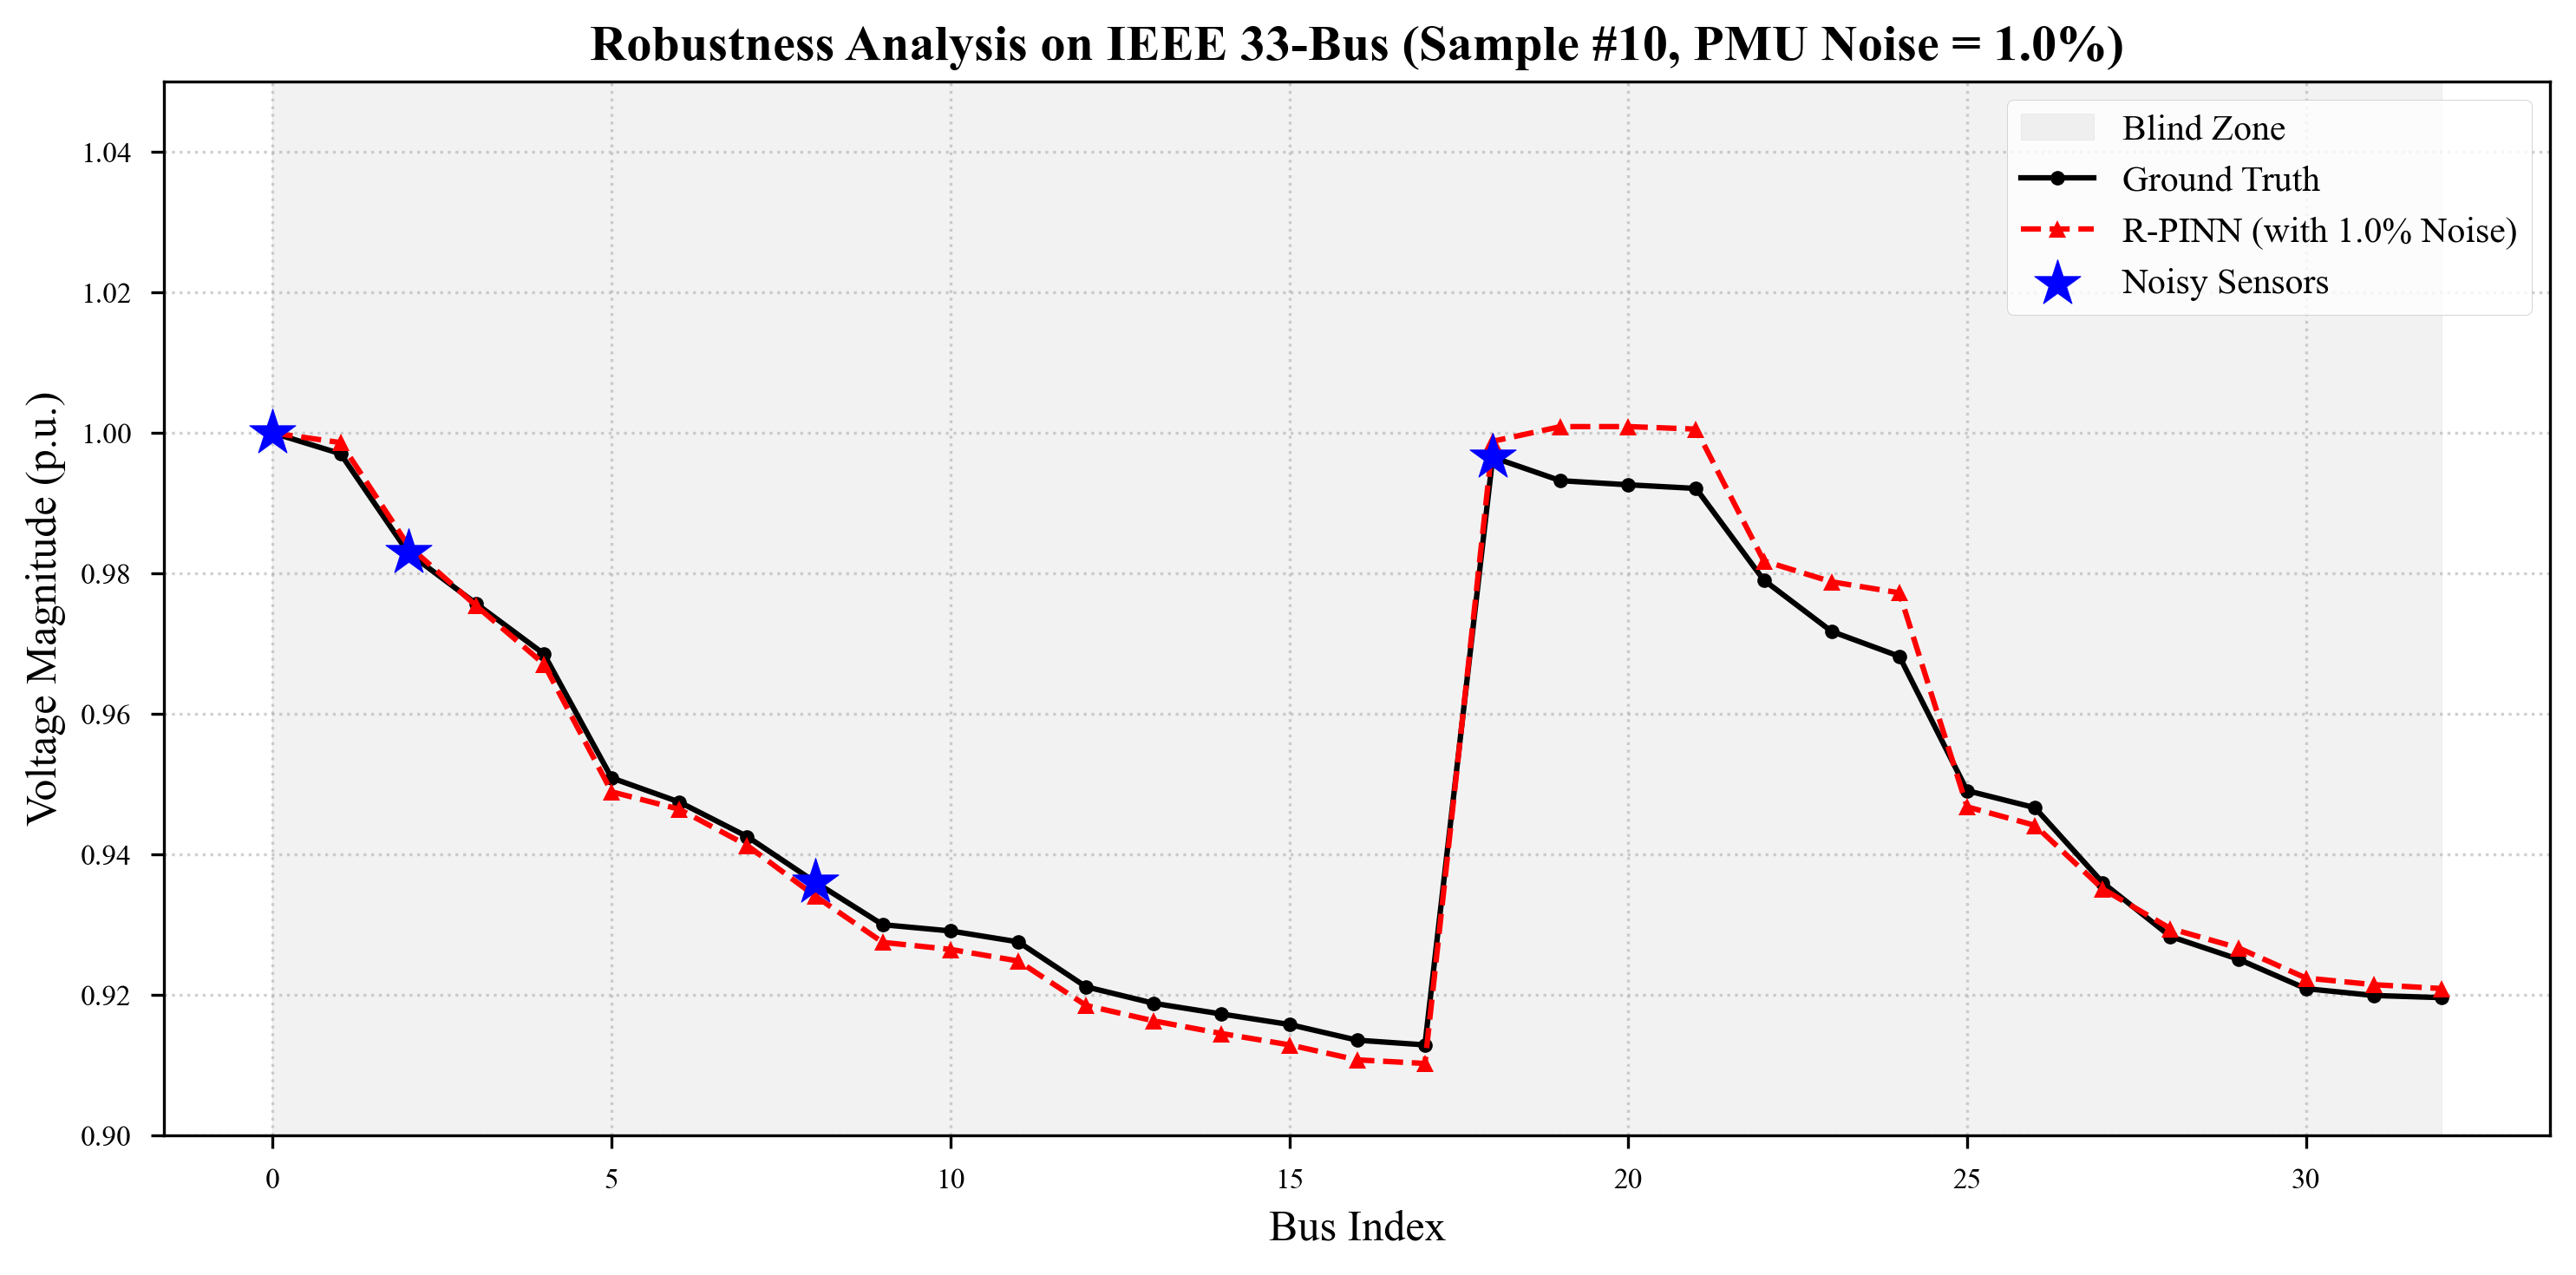

In [2]:
# ==============================================================================
# [Cell 7] 鲁棒性终极测试 (PMU Measurement Noise Test)
# 目的：给 15% 的 PMU 传感器注入高斯白噪声，验证物理约束的极限抗干扰能力
# ==============================================================================

# 🚀 1. 考卷定格：强制对齐观测点
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 
TEST_NOISE_LEVEL = 0.01

print(f"🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: {TEST_NOISE_LEVEL*100}% | 观测点: {obs_indices}")

# 2. 实例化全新的测试模型与 Loss
model_noise = PowerGridPINN(input_dim=66).to(device)

# 3. 初始化偏置
with torch.no_grad():
    model_noise.output_layers.bias[:33].fill_(-0.5)

pinn_loss_noise = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_noise = torch.optim.Adam(model_noise.parameters(), lr=0.001)
scheduler_noise = torch.optim.lr_scheduler.StepLR(optimizer_noise, step_size=40, gamma=0.5) 

# 4. 深度训练循环 (带噪声注入)
max_epoch = 150
for epoch in range(max_epoch):
    p_weight = 1000 if epoch < 50 else 5000
    model_noise.train()
    
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_noise.zero_grad()
        
        # 解析真实值
        real_p = batch_all_targets[:, :33]
        real_q = batch_all_targets[:, 33:66]
        real_v = batch_all_targets[:, 66:]
        
        # 应用 15% 观测遮蔽
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型推理 (V_guess)
        V_guess, theta_guess = model_noise(mask_x)
        
        # ========================================================
        # ⚠️ 核心：精准切片注入传感器噪声
        noisy_V = real_v.clone()
        clean_obs_v = noisy_V[:, obs_indices] # 提取 15% 真实观测值
        
        # 生成对应形状的随机高斯矩阵，并按比例注入
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_V[:, obs_indices] = clean_obs_v + clean_obs_v * noise_matrix
        # ========================================================

        # 核心：用被污染的 noisy_V 去计算观测 Loss，骗过网络
        loss = pinn_loss_noise(V_guess, theta_guess, real_p, real_q, noisy_V, p_weight, obs_weight=500000)
        
        loss.backward()
        optimizer_noise.step()
        running_loss += loss.item()
    
    scheduler_noise.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer_noise.param_groups[0]['lr']}")

# 5. 最终指标结算 (依然用最干净的 real_Vm 来算误差！)
model_noise.eval()
with torch.no_grad():
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_noise_tensor, _ = model_noise(masked_test_X)
    pred_Vm_noise = pred_Vm_noise_tensor.cpu().numpy()
    
    error_noise = pred_Vm_noise - real_Vm
    mae_noise = np.mean(np.abs(error_noise))
    rmse_noise = np.sqrt(np.mean(error_noise**2)) # 👈 仅在这里为你新增了RMSE的计算

print("\n" + "="*65)
print(f"🛡️ [鲁棒性测试结果] Noise Level: {TEST_NOISE_LEVEL*100}%")
print("-" * 65)
print(f"🌍 MAE under {TEST_NOISE_LEVEL*100}% Noise:  {mae_noise:.6e} p.u.")
print(f"🔥 RMSE under {TEST_NOISE_LEVEL*100}% Noise: {rmse_noise:.6e} p.u.") # 👈 仅在这里为你新增了RMSE的打印输出
print("="*65)

# ==========================================
# 6. 学术级英文绘图 (抗噪声表现)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper') 

sample_idx = 10 
v_true = data_3d[sample_idx, :, 2]

with torch.no_grad():
    test_input = X_tensor[sample_idx:sample_idx+1]
    masked_input = apply_blind_zone(test_input, obs_indices, mean_tensor, scale_tensor)
    v_p_noise_plot = model_noise(masked_input)[0].cpu().numpy().flatten()

nodes = np.arange(33)
plt.figure(figsize=(10, 5), dpi=300) 

plt.axvspan(0, 32, color='gray', alpha=0.1, label='Blind Zone')

# 画出绝对真理和扛着噪声跑出来的结果
plt.plot(nodes, v_true, 'k-o', label='Ground Truth', markersize=4, linewidth=1.5)
plt.plot(nodes, v_p_noise_plot, 'r--^', label=f'R-PINN (with {TEST_NOISE_LEVEL*100}% Noise)', markersize=5, linewidth=1.5)

plt.scatter(obs_indices, v_true[obs_indices], color='blue', marker='*', s=180, zorder=5, label='Noisy Sensors')

plt.title(f"Robustness Analysis on IEEE 33-Bus (Sample #{sample_idx}, PMU Noise = {TEST_NOISE_LEVEL*100}%)", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index", fontsize=12)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=12)
plt.ylim(0.9, 1.05) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.tight_layout()

# 保存带噪声水平后缀的高清图
plt.savefig(f'ieee33_robustness_{int(TEST_NOISE_LEVEL*100)}percent.png', dpi=600)
plt.show()

🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: 2.0% | 观测点: [0, 2, 8, 18]
Epoch 0   | Avg Loss: 385965.1657 | LR: 0.001
Epoch 10  | Avg Loss: 98760.3555 | LR: 0.001
Epoch 20  | Avg Loss: 98648.0075 | LR: 0.001
Epoch 30  | Avg Loss: 98667.7341 | LR: 0.001
Epoch 40  | Avg Loss: 99043.4641 | LR: 0.0005
Epoch 50  | Avg Loss: 99808.7189 | LR: 0.0005
Epoch 60  | Avg Loss: 100034.9551 | LR: 0.0005
Epoch 70  | Avg Loss: 100200.1573 | LR: 0.0005
Epoch 80  | Avg Loss: 99390.2237 | LR: 0.00025
Epoch 90  | Avg Loss: 99141.2974 | LR: 0.00025
Epoch 100 | Avg Loss: 99970.8916 | LR: 0.00025
Epoch 110 | Avg Loss: 99433.5768 | LR: 0.00025
Epoch 120 | Avg Loss: 99814.6603 | LR: 0.000125
Epoch 130 | Avg Loss: 99708.6930 | LR: 0.000125
Epoch 140 | Avg Loss: 99959.6883 | LR: 0.000125

🛡️ [鲁棒性测试结果] Noise Level: 2.0%
-----------------------------------------------------------------
🌍 MAE under 2.0% Noise:  3.144423e-03 p.u.
🔥 RMSE under 2.0% Noise: 4.298511e-03 p.u.


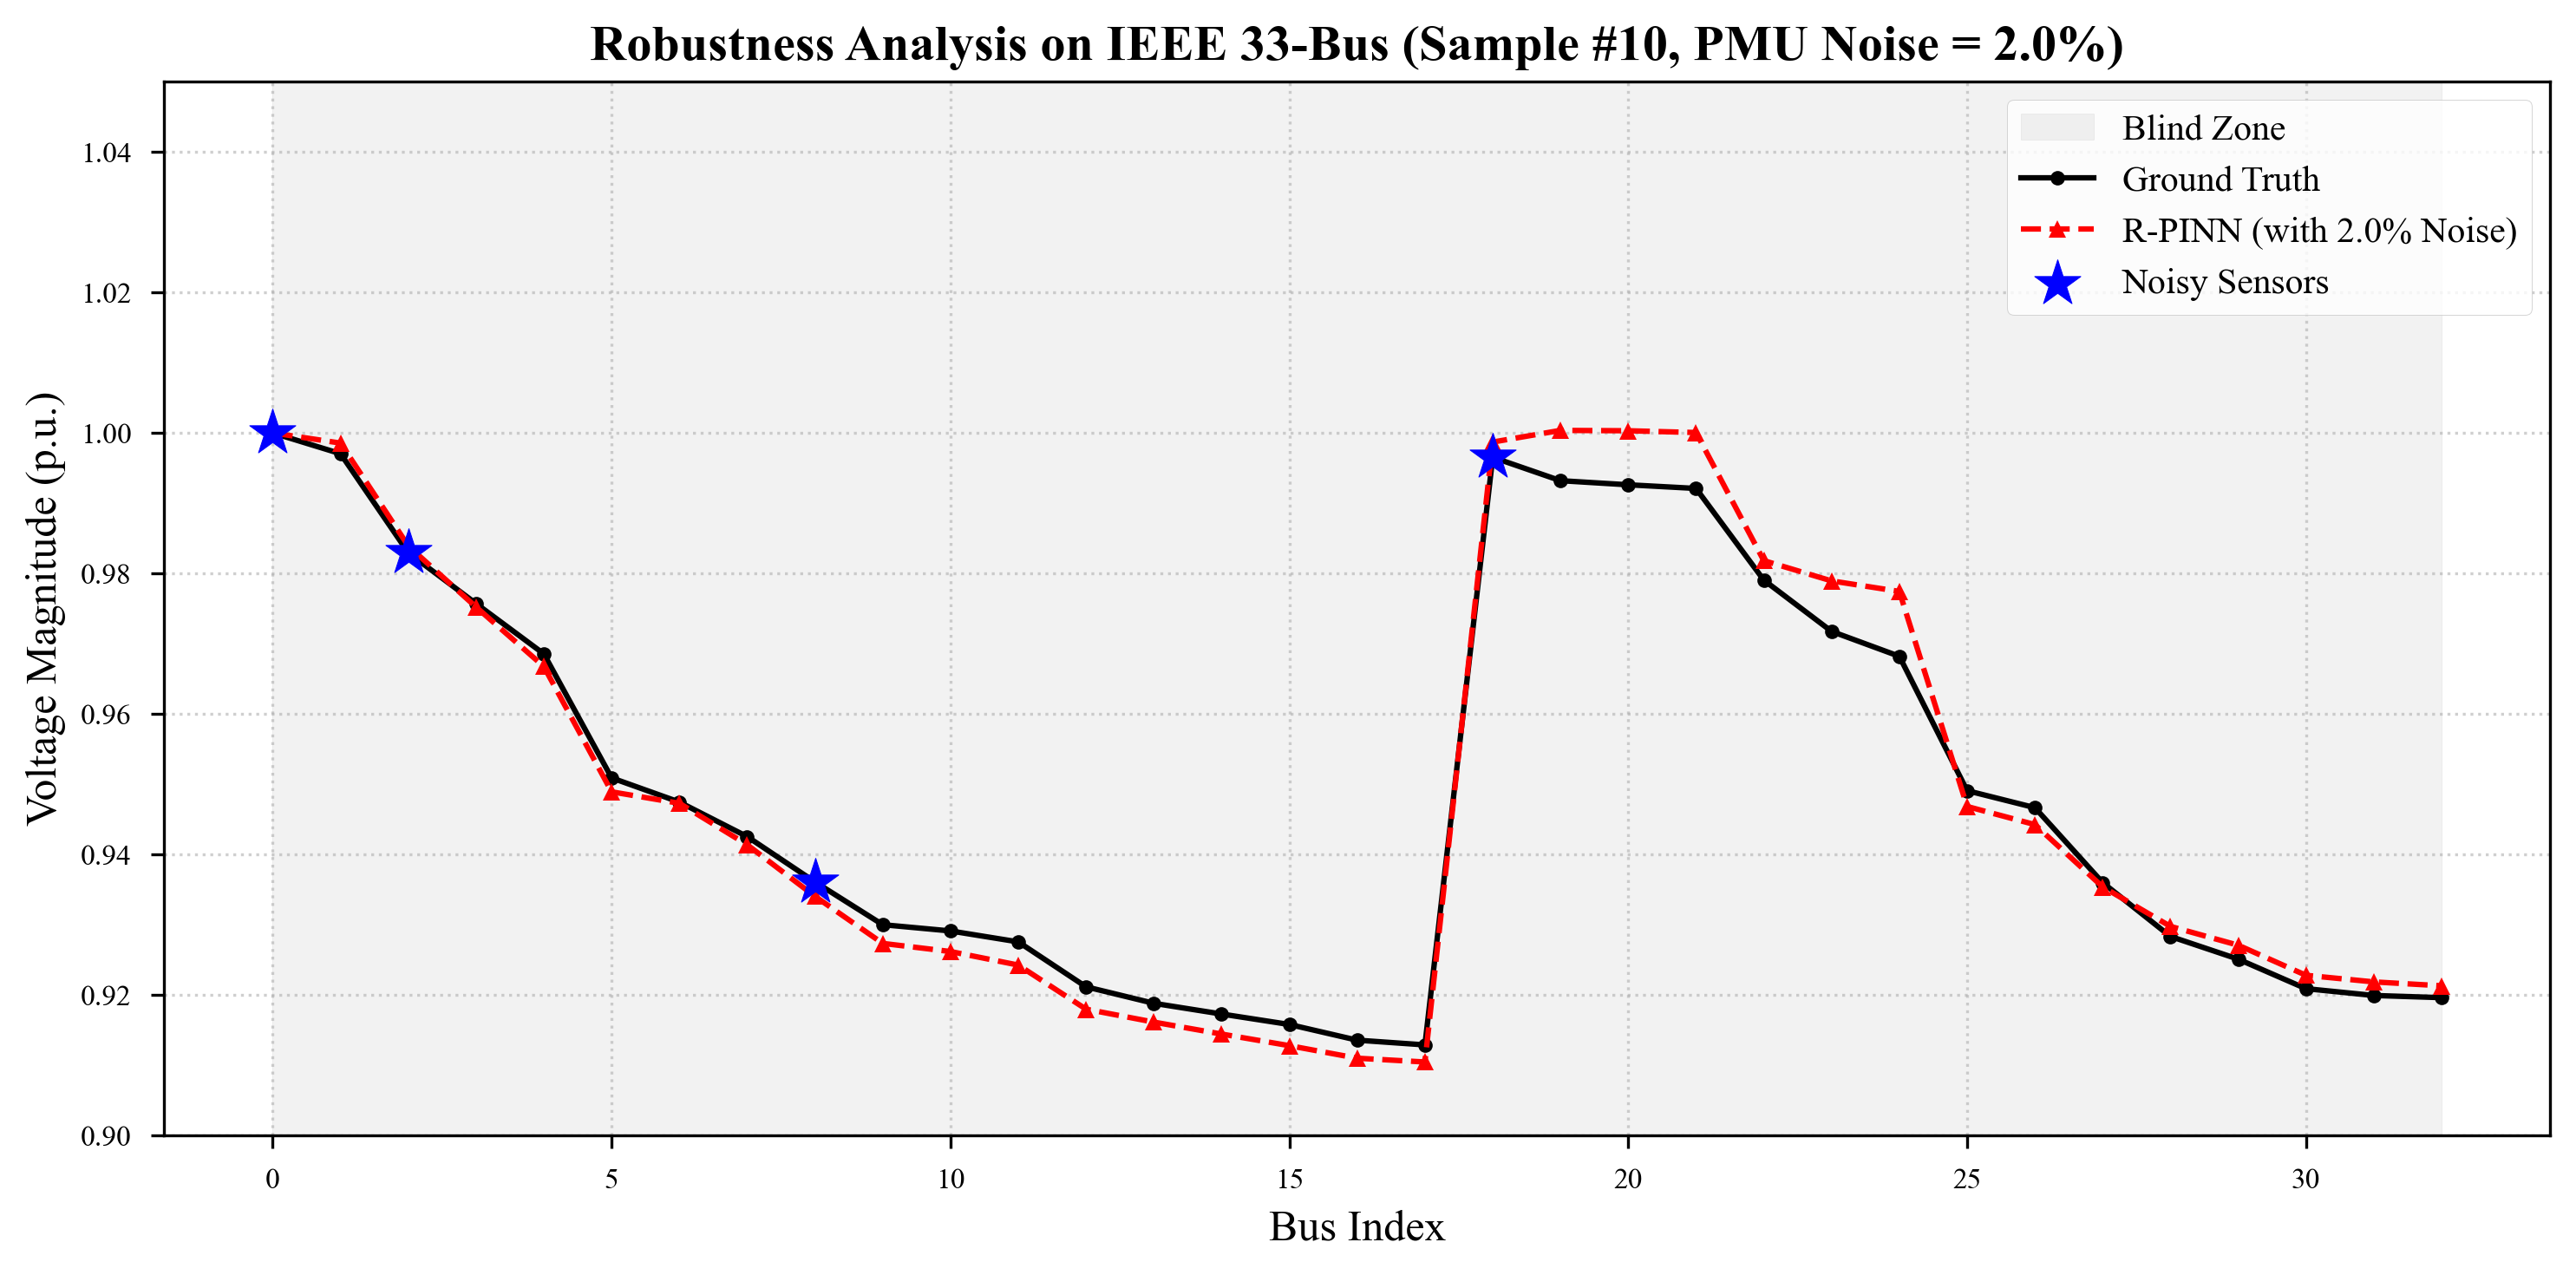

In [3]:
# ==============================================================================
# [Cell 7] 鲁棒性终极测试 (PMU Measurement Noise Test)
# 目的：给 15% 的 PMU 传感器注入高斯白噪声，验证物理约束的极限抗干扰能力
# ==============================================================================

# 🚀 1. 考卷定格：强制对齐观测点
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 
TEST_NOISE_LEVEL = 0.02

print(f"🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: {TEST_NOISE_LEVEL*100}% | 观测点: {obs_indices}")

# 2. 实例化全新的测试模型与 Loss
model_noise = PowerGridPINN(input_dim=66).to(device)

# 3. 初始化偏置
with torch.no_grad():
    model_noise.output_layers.bias[:33].fill_(-0.5)

pinn_loss_noise = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_noise = torch.optim.Adam(model_noise.parameters(), lr=0.001)
scheduler_noise = torch.optim.lr_scheduler.StepLR(optimizer_noise, step_size=40, gamma=0.5) 

# 4. 深度训练循环 (带噪声注入)
max_epoch = 150
for epoch in range(max_epoch):
    p_weight = 1000 if epoch < 50 else 5000
    model_noise.train()
    
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_noise.zero_grad()
        
        # 解析真实值
        real_p = batch_all_targets[:, :33]
        real_q = batch_all_targets[:, 33:66]
        real_v = batch_all_targets[:, 66:]
        
        # 应用 15% 观测遮蔽
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型推理 (V_guess)
        V_guess, theta_guess = model_noise(mask_x)
        
        # ========================================================
        # ⚠️ 核心：精准切片注入传感器噪声
        noisy_V = real_v.clone()
        clean_obs_v = noisy_V[:, obs_indices] # 提取 15% 真实观测值
        
        # 生成对应形状的随机高斯矩阵，并按比例注入
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_V[:, obs_indices] = clean_obs_v + clean_obs_v * noise_matrix
        # ========================================================

        # 核心：用被污染的 noisy_V 去计算观测 Loss，骗过网络
        loss = pinn_loss_noise(V_guess, theta_guess, real_p, real_q, noisy_V, p_weight, obs_weight=500000)
        
        loss.backward()
        optimizer_noise.step()
        running_loss += loss.item()
    
    scheduler_noise.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer_noise.param_groups[0]['lr']}")

# 5. 最终指标结算 (依然用最干净的 real_Vm 来算误差！)
model_noise.eval()
with torch.no_grad():
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_noise_tensor, _ = model_noise(masked_test_X)
    pred_Vm_noise = pred_Vm_noise_tensor.cpu().numpy()
    
    error_noise = pred_Vm_noise - real_Vm
    mae_noise = np.mean(np.abs(error_noise))
    rmse_noise = np.sqrt(np.mean(error_noise**2)) # 👈 仅在这里为你新增了RMSE的计算

print("\n" + "="*65)
print(f"🛡️ [鲁棒性测试结果] Noise Level: {TEST_NOISE_LEVEL*100}%")
print("-" * 65)
print(f"🌍 MAE under {TEST_NOISE_LEVEL*100}% Noise:  {mae_noise:.6e} p.u.")
print(f"🔥 RMSE under {TEST_NOISE_LEVEL*100}% Noise: {rmse_noise:.6e} p.u.") # 👈 仅在这里为你新增了RMSE的打印输出
print("="*65)

# ==========================================
# 6. 学术级英文绘图 (抗噪声表现)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper') 

sample_idx = 10 
v_true = data_3d[sample_idx, :, 2]

with torch.no_grad():
    test_input = X_tensor[sample_idx:sample_idx+1]
    masked_input = apply_blind_zone(test_input, obs_indices, mean_tensor, scale_tensor)
    v_p_noise_plot = model_noise(masked_input)[0].cpu().numpy().flatten()

nodes = np.arange(33)
plt.figure(figsize=(10, 5), dpi=300) 

plt.axvspan(0, 32, color='gray', alpha=0.1, label='Blind Zone')

# 画出绝对真理和扛着噪声跑出来的结果
plt.plot(nodes, v_true, 'k-o', label='Ground Truth', markersize=4, linewidth=1.5)
plt.plot(nodes, v_p_noise_plot, 'r--^', label=f'R-PINN (with {TEST_NOISE_LEVEL*100}% Noise)', markersize=5, linewidth=1.5)

plt.scatter(obs_indices, v_true[obs_indices], color='blue', marker='*', s=180, zorder=5, label='Noisy Sensors')

plt.title(f"Robustness Analysis on IEEE 33-Bus (Sample #{sample_idx}, PMU Noise = {TEST_NOISE_LEVEL*100}%)", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index", fontsize=12)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=12)
plt.ylim(0.9, 1.05) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.tight_layout()

# 保存带噪声水平后缀的高清图
plt.savefig(f'ieee33_robustness_{int(TEST_NOISE_LEVEL*100)}percent.png', dpi=600)
plt.show()

🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: 3.0% | 观测点: [0, 2, 8, 18]
Epoch 0   | Avg Loss: 511573.6861 | LR: 0.001
Epoch 10  | Avg Loss: 221053.5324 | LR: 0.001
Epoch 20  | Avg Loss: 220946.4189 | LR: 0.001
Epoch 30  | Avg Loss: 220802.5952 | LR: 0.001
Epoch 40  | Avg Loss: 222095.3816 | LR: 0.0005
Epoch 50  | Avg Loss: 222212.5536 | LR: 0.0005
Epoch 60  | Avg Loss: 222730.8632 | LR: 0.0005
Epoch 70  | Avg Loss: 223079.7648 | LR: 0.0005
Epoch 80  | Avg Loss: 221324.2936 | LR: 0.00025
Epoch 90  | Avg Loss: 220799.2934 | LR: 0.00025
Epoch 100 | Avg Loss: 222711.1604 | LR: 0.00025
Epoch 110 | Avg Loss: 221546.3477 | LR: 0.00025
Epoch 120 | Avg Loss: 222396.1783 | LR: 0.000125
Epoch 130 | Avg Loss: 222103.8646 | LR: 0.000125
Epoch 140 | Avg Loss: 222612.1687 | LR: 0.000125

🛡️ [鲁棒性测试结果] Noise Level: 3.0%
-----------------------------------------------------------------
🌍 MAE under 3.0% Noise:  3.206339e-03 p.u.
🔥 RMSE under 3.0% Noise: 4.381212e-03 p.u.


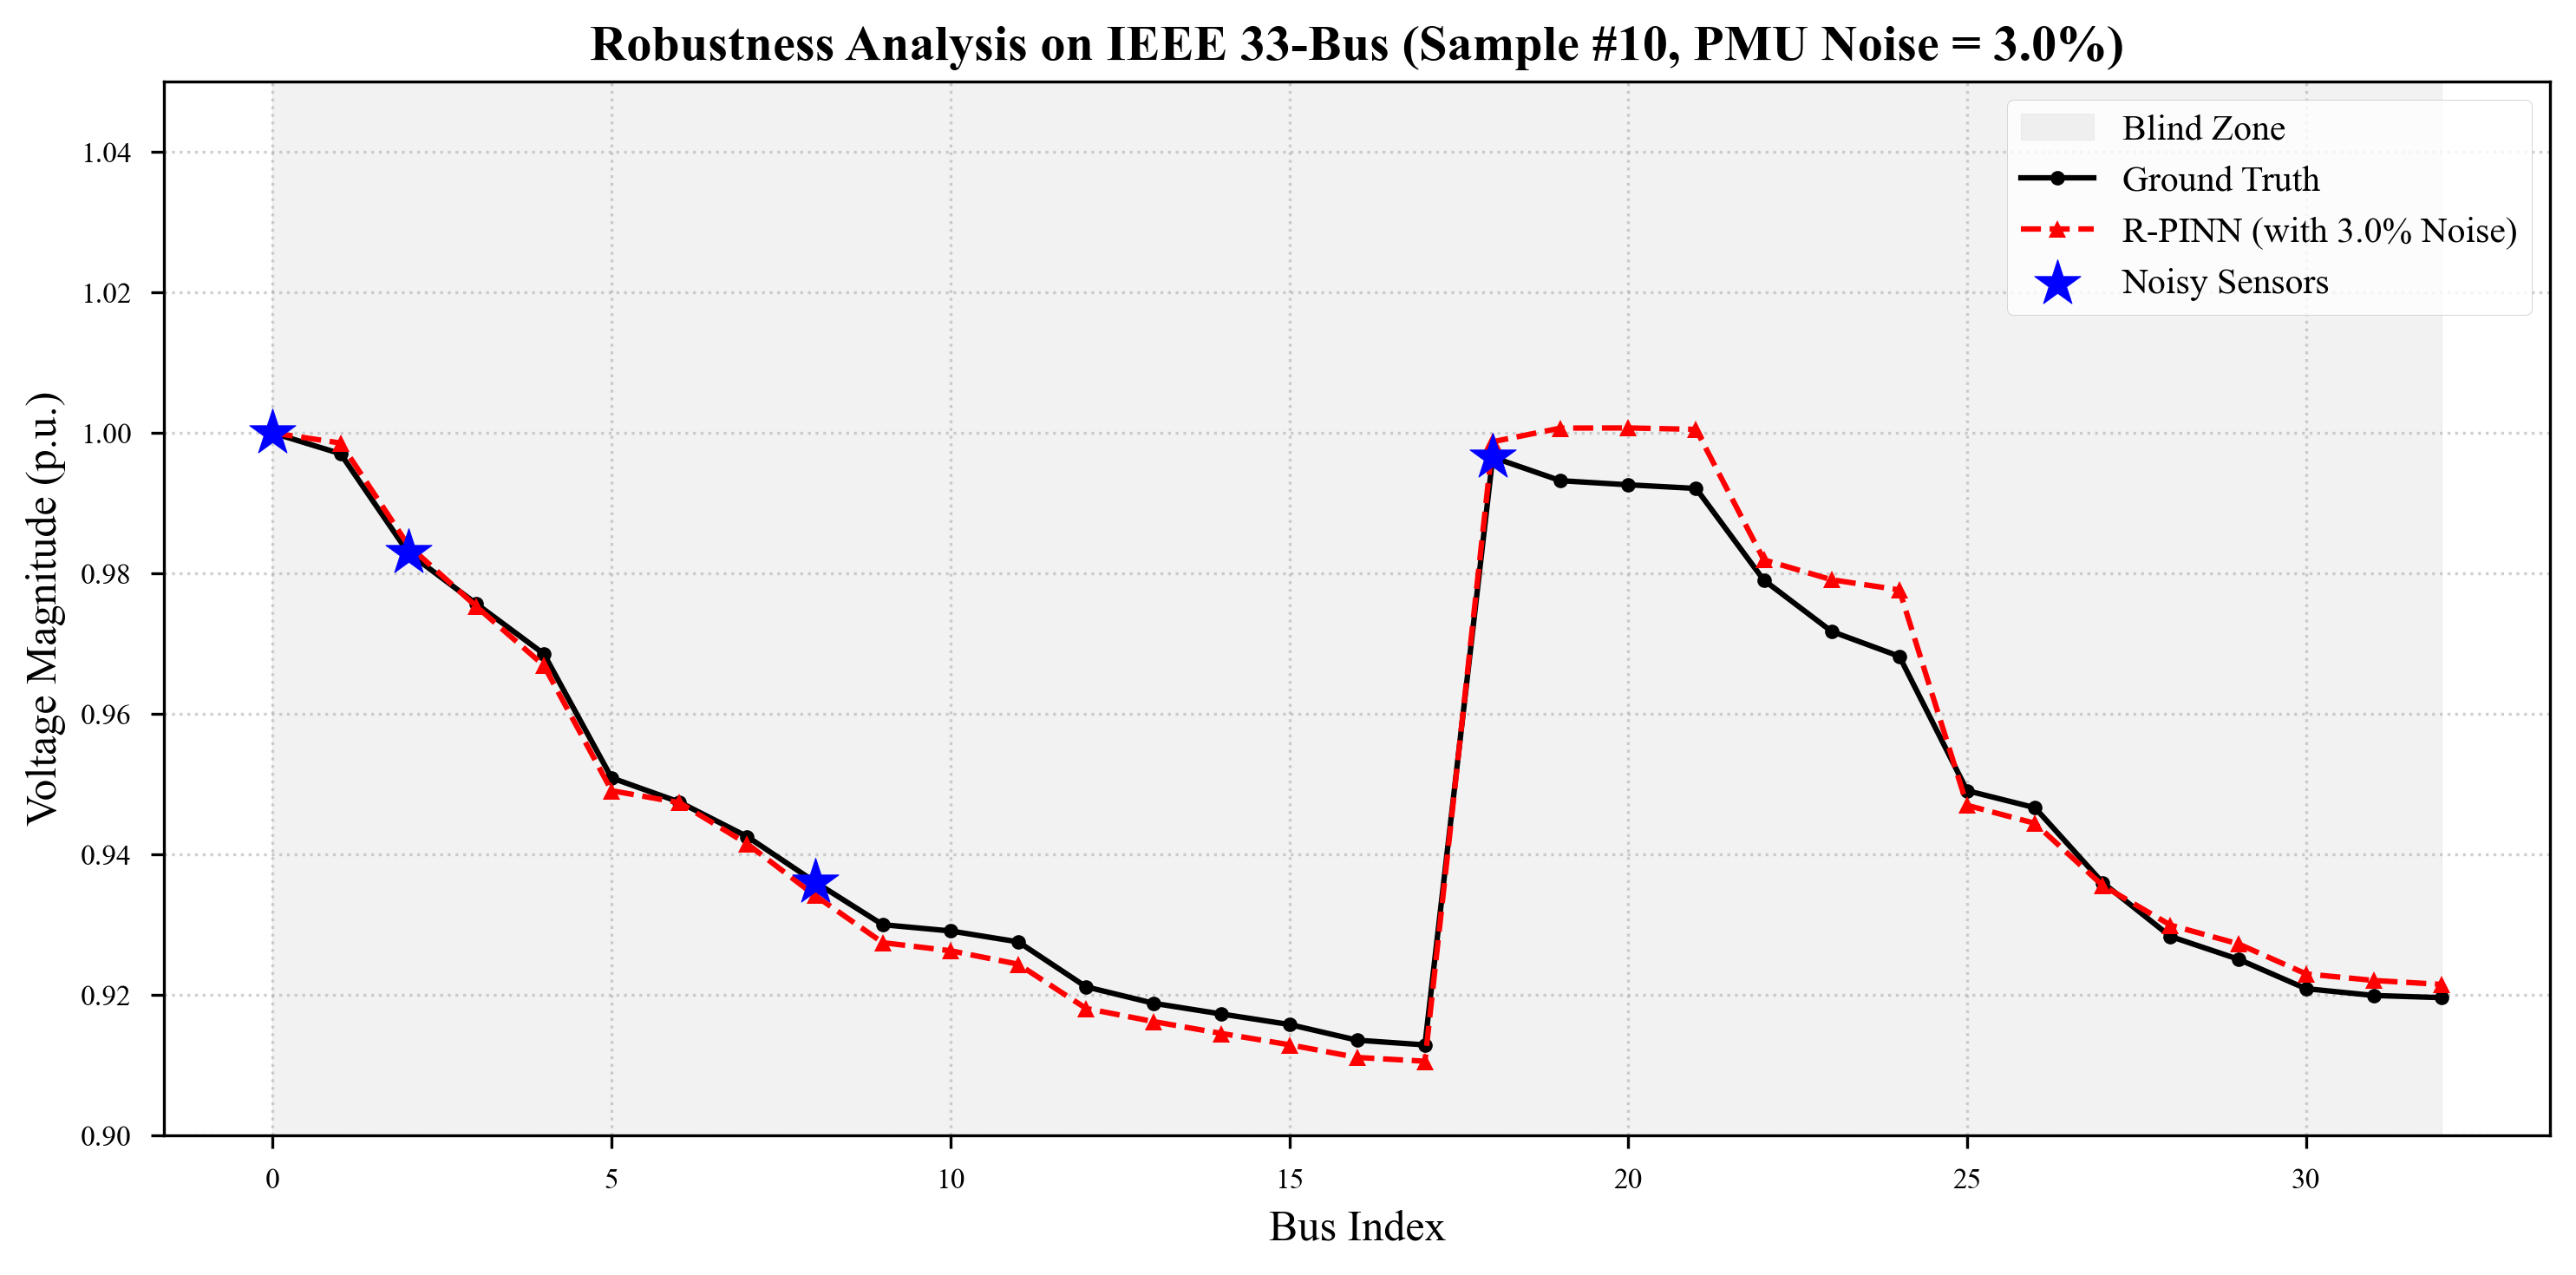

In [4]:
# ==============================================================================
# [Cell 7] 鲁棒性终极测试 (PMU Measurement Noise Test)
# 目的：给 15% 的 PMU 传感器注入高斯白噪声，验证物理约束的极限抗干扰能力
# ==============================================================================

# 🚀 1. 考卷定格：强制对齐观测点
set_seed(42) 
obs_indices = get_obs_indices(33, 42) 
TEST_NOISE_LEVEL = 0.03

print(f"🚀 [鲁棒性测试] 启动 | 当前 PMU 噪声水平: {TEST_NOISE_LEVEL*100}% | 观测点: {obs_indices}")

# 2. 实例化全新的测试模型与 Loss
model_noise = PowerGridPINN(input_dim=66).to(device)

# 3. 初始化偏置
with torch.no_grad():
    model_noise.output_layers.bias[:33].fill_(-0.5)

pinn_loss_noise = PowerPINNLoss(G_tensor, B_tensor, obs_indices)
optimizer_noise = torch.optim.Adam(model_noise.parameters(), lr=0.001)
scheduler_noise = torch.optim.lr_scheduler.StepLR(optimizer_noise, step_size=40, gamma=0.5) 

# 4. 深度训练循环 (带噪声注入)
max_epoch = 150
for epoch in range(max_epoch):
    p_weight = 1000 if epoch < 50 else 5000
    model_noise.train()
    
    running_loss = 0.0
    for batch_x, batch_all_targets in train_loader:
        optimizer_noise.zero_grad()
        
        # 解析真实值
        real_p = batch_all_targets[:, :33]
        real_q = batch_all_targets[:, 33:66]
        real_v = batch_all_targets[:, 66:]
        
        # 应用 15% 观测遮蔽
        mask_x = apply_blind_zone(batch_x, obs_indices, mean_tensor, scale_tensor)
        
        # 模型推理 (V_guess)
        V_guess, theta_guess = model_noise(mask_x)
        
        # ========================================================
        # ⚠️ 核心：精准切片注入传感器噪声
        noisy_V = real_v.clone()
        clean_obs_v = noisy_V[:, obs_indices] # 提取 15% 真实观测值
        
        # 生成对应形状的随机高斯矩阵，并按比例注入
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_V[:, obs_indices] = clean_obs_v + clean_obs_v * noise_matrix
        # ========================================================

        # 核心：用被污染的 noisy_V 去计算观测 Loss，骗过网络
        loss = pinn_loss_noise(V_guess, theta_guess, real_p, real_q, noisy_V, p_weight, obs_weight=500000)
        
        loss.backward()
        optimizer_noise.step()
        running_loss += loss.item()
    
    scheduler_noise.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3} | Avg Loss: {running_loss/len(train_loader):.4f} | LR: {optimizer_noise.param_groups[0]['lr']}")

# 5. 最终指标结算 (依然用最干净的 real_Vm 来算误差！)
model_noise.eval()
with torch.no_grad():
    test_X = X_tensor[:1000]
    real_Vm = data_3d[:1000, :, 2]
    masked_test_X = apply_blind_zone(test_X, obs_indices, mean_tensor, scale_tensor)
    
    pred_Vm_noise_tensor, _ = model_noise(masked_test_X)
    pred_Vm_noise = pred_Vm_noise_tensor.cpu().numpy()
    
    error_noise = pred_Vm_noise - real_Vm
    mae_noise = np.mean(np.abs(error_noise))
    rmse_noise = np.sqrt(np.mean(error_noise**2)) # 👈 仅在这里为你新增了RMSE的计算

print("\n" + "="*65)
print(f"🛡️ [鲁棒性测试结果] Noise Level: {TEST_NOISE_LEVEL*100}%")
print("-" * 65)
print(f"🌍 MAE under {TEST_NOISE_LEVEL*100}% Noise:  {mae_noise:.6e} p.u.")
print(f"🔥 RMSE under {TEST_NOISE_LEVEL*100}% Noise: {rmse_noise:.6e} p.u.") # 👈 仅在这里为你新增了RMSE的打印输出
print("="*65)

# ==========================================
# 6. 学术级英文绘图 (抗噪声表现)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper') 

sample_idx = 10 
v_true = data_3d[sample_idx, :, 2]

with torch.no_grad():
    test_input = X_tensor[sample_idx:sample_idx+1]
    masked_input = apply_blind_zone(test_input, obs_indices, mean_tensor, scale_tensor)
    v_p_noise_plot = model_noise(masked_input)[0].cpu().numpy().flatten()

nodes = np.arange(33)
plt.figure(figsize=(10, 5), dpi=300) 

plt.axvspan(0, 32, color='gray', alpha=0.1, label='Blind Zone')

# 画出绝对真理和扛着噪声跑出来的结果
plt.plot(nodes, v_true, 'k-o', label='Ground Truth', markersize=4, linewidth=1.5)
plt.plot(nodes, v_p_noise_plot, 'r--^', label=f'R-PINN (with {TEST_NOISE_LEVEL*100}% Noise)', markersize=5, linewidth=1.5)

plt.scatter(obs_indices, v_true[obs_indices], color='blue', marker='*', s=180, zorder=5, label='Noisy Sensors')

plt.title(f"Robustness Analysis on IEEE 33-Bus (Sample #{sample_idx}, PMU Noise = {TEST_NOISE_LEVEL*100}%)", fontsize=14, fontweight='bold')
plt.xlabel("Bus Index", fontsize=12)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=12)
plt.ylim(0.9, 1.05) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=10, frameon=True)
plt.tight_layout()

# 保存带噪声水平后缀的高清图
plt.savefig(f'ieee33_robustness_{int(TEST_NOISE_LEVEL*100)}percent.png', dpi=600)
plt.show()

In [5]:
# ==============================================================================
# 🔥 [Cell 3.5] 炼丹炉点火：33 节点 R-PINN 深度学习训练循环
# ==============================================================================
import torch.optim as optim

# 1. 实例化模型与优化器
# 这里的 model 变量名必须与你后面结算单里的 model 对齐
model = PowerGridPINN(input_dim=66).to(device)

# 💡 专家级初始化：让输出层的偏置微调，使得初始预测值就在 1.0 p.u. 附近
with torch.no_grad():
    model.output_layers.bias[:33].fill_(-0.5)

# 2. 定义损失函数与优化器
# 使用你在 Cell 2 中定义的物理 Loss 和 15% 观测点索引
pinn_loss_func = PowerPINNLoss(G_tensor, B_tensor, global_obs_indices)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# 学习率阶梯衰减，每 40 步砍掉一半，防止后期振荡
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)

# 3. 开始炼丹
num_epochs = 150
print(f"🔥 开始训练 33 节点 R-PINN模型 | 观测点: {global_obs_indices}")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    # 动态物理权重：前 50 步先让模型“认全数据”，50 步后加大物理方程的约束力
    p_weight = 1000 if epoch < 50 else 5000
    
    for batch_x, batch_targets in train_loader:
        optimizer.zero_grad()
        
        # a. 模拟 PMU 盲区：只给模型看 15% 的输入特征
        mask_x = apply_blind_zone(batch_x, global_obs_indices, mean_tensor, scale_tensor)
        
        # b. 前向传播
        V_pred, theta_pred = model(mask_x)
        
        # c. 计算三合一 Loss (物理残差 + 观测点数据 + 电压越限处罚)
        # batch_targets 结构: [P_real, Q_real, V_real]
        loss = pinn_loss_func(
            V_pred, theta_pred, 
            batch_targets[:, :33],   # P_real
            batch_targets[:, 33:66],  # Q_real
            batch_targets[:, 66:],    # V_real
            p_weight
        )
        
        # d. 反向传播与优化
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    scheduler.step()
    
    # 每 10 个 Epoch 打印一次战报
    if epoch % 10 == 0 or epoch == num_epochs - 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch:>3}/{num_epochs}] | Loss: {running_loss/len(train_loader):.6f} | LR: {current_lr:.6f} | P-Weight: {p_weight}")

print("✅ 训练完成！你的 R-PINN 模型现在已经具备了强大的物理直觉。")

🔥 开始训练 33 节点 R-PINN模型 | 观测点: [0, 2, 8, 18]
Epoch [  0/150] | Loss: 90044.179023 | LR: 0.001000 | P-Weight: 1000
Epoch [ 10/150] | Loss: 567.708084 | LR: 0.001000 | P-Weight: 1000
Epoch [ 20/150] | Loss: 566.046797 | LR: 0.001000 | P-Weight: 1000
Epoch [ 30/150] | Loss: 545.003023 | LR: 0.001000 | P-Weight: 1000
Epoch [ 40/150] | Loss: 523.314491 | LR: 0.000500 | P-Weight: 1000
Epoch [ 50/150] | Loss: 7021.778579 | LR: 0.000500 | P-Weight: 5000
Epoch [ 60/150] | Loss: 1815.659066 | LR: 0.000500 | P-Weight: 5000
Epoch [ 70/150] | Loss: 1806.128103 | LR: 0.000500 | P-Weight: 5000
Epoch [ 80/150] | Loss: 1792.678709 | LR: 0.000250 | P-Weight: 5000
Epoch [ 90/150] | Loss: 1793.038113 | LR: 0.000250 | P-Weight: 5000
Epoch [100/150] | Loss: 1791.348398 | LR: 0.000250 | P-Weight: 5000
Epoch [110/150] | Loss: 1792.820313 | LR: 0.000250 | P-Weight: 5000
Epoch [120/150] | Loss: 1788.309877 | LR: 0.000125 | P-Weight: 5000
Epoch [130/150] | Loss: 1788.610432 | LR: 0.000125 | P-Weight: 5000
Epoch [1

In [6]:
# ==============================================================================
# 🏆 [Cell 4] 33-Bus N-1 拓扑感知零样本大考结算单 (包含 MAE & RMSE)
# ==============================================================================
import torch
import numpy as np
import pandas as pd

# 🧭 1. 物理连通性探测引擎 (基于 G & B 矩阵)
def get_topology_mask(G, B, root=0):
    """
    像水流一样从 0 号平衡节点出发，只要导纳非零就蔓延，
    最终找不到的地方就是断电孤岛 (置为 0)
    """
    n = G.shape[0]
    visited = np.zeros(n, dtype=np.float32)
    queue = [root]
    visited[root] = 1.0
    while queue:
        curr = queue.pop(0)
        for nxt in range(n):
            # 只要电导 (G) 或电纳 (B) 非零，物理上就依然连通
            is_connected = abs(G[curr, nxt]) > 1e-6 or abs(B[curr, nxt]) > 1e-6
            if curr != nxt and is_connected and visited[nxt] == 0.0:
                visited[nxt] = 1.0
                queue.append(nxt)
    return visited

# ⚠️ 确保你的模型已经训练完毕，且变量名是 model
# 如果你的模型叫其他名字，请把这里的 model 替换掉
model.eval() 
cases = ["C1", "C2", "C3"]

print("\n" + "📊"*16 + "\n 🏁 IEEE 33-Bus N-1 拓扑感知结算单 \n" + "📊"*16)

with torch.no_grad():
    for c in cases:
        try:
            # 2. 读数 & 极限防御 NaN/Inf
            # N-1 断网会导致 Pandapower 吐出 NaN，直接拍成 0，符合物理事实
            df = pd.read_csv(f"data_33_{c}.csv").fillna(0)
            if df.empty:
                print(f"⚠️ {c} 失败: CSV 文件为空，请检查生成步骤！")
                continue
                
            raw_val = df.values
            raw_val[np.isinf(raw_val)] = 0 
            n_samples = len(df)
            
            # 3. 严格遵循你 Cell 3 的维度重塑逻辑 [样本数, 33, 4]
            data_3d = raw_val.reshape(n_samples, 33, 4)
            V_real = data_3d[:, :, 2] # 真实电压标幺值
            
            # 提取 P, Q (前两个特征) 并展开成 66 维
            X_raw = data_3d[:, :, 0:2].reshape(n_samples, 66)
            
            # 使用你在 Cell 3 中 fit 好的 ssl 对象进行归一化！
            X_norm = ssl.transform(X_raw) 
            X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)
            
            # 使用你在 Cell 2 中定义的遮蔽引擎
            mask_x = apply_blind_zone(X_tensor, global_obs_indices, mean_tensor, scale_tensor)
            
            # 4. 🛡️ 核心：加载对应的 G 和 B，生成物理拓扑面具
            G_N1 = np.load(f'G_33_{c}.npy')
            B_N1 = np.load(f'B_33_{c}.npy')
            topo_mask_np = get_topology_mask(G_N1, B_N1, root=0) 
            topo_mask_tensor = torch.tensor(topo_mask_np, dtype=torch.float32).unsqueeze(0).to(device)
            
            # 5. 推理 & 外部强制拓扑感知
            # 模型基于残差预测出来的全网电压 (没改内部代码，所以孤岛可能预测出 1.0)
            V_pred_tensor, _ = model(mask_x)
            
            # ⚔️ 外部一刀切：用面具直接封杀孤岛节点电压 (1.0 * 0 = 0)
            V_pred_tensor = V_pred_tensor * topo_mask_tensor
            V_pred = V_pred_tensor.cpu().numpy()
            
            # 6. 极致核算误差 (MAE & RMSE 双轨制)
            error = V_pred - V_real
            mae = np.mean(np.abs(error))
            rmse = np.sqrt(np.mean(error**2))
            
            # 统计有多少个节点彻底断电了
            dead_nodes = 33 - int(np.sum(topo_mask_np))
            
            print(f"⚡ Case {c} | 孤岛死区: {dead_nodes:<2} 个 | MAE: {mae:.6e} p.u. | RMSE: {rmse:.6e} p.u.")
            
        except FileNotFoundError as e:
            print(f"❌ {c} 测试失败: 找不到对应的数据或矩阵文件 ({e.filename})")
        except Exception as e:
            print(f"❌ {c} 测试异常: {e}")
            
print("="*48)


📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
 🏁 IEEE 33-Bus N-1 拓扑感知结算单 
📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊📊
❌ C1 测试异常: index 0 is out of bounds for axis 0 with size 0
❌ C2 测试异常: index 0 is out of bounds for axis 0 with size 0
❌ C3 测试异常: index 0 is out of bounds for axis 0 with size 0
